In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Overview

In [2]:
df = pd.read_csv('train.csv')
df.columns = df.columns.str.lower()
df.head()
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    str    
 4   sex          891 non-null    str    
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    str    
 9   fare         891 non-null    float64
 10  cabin        204 non-null    str    
 11  embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Observations

1. The dataset contains 891 samples and 12 variables, including both numerical and categorical features.  
2. Survival: The overall survival rate is about 38.38%.  
3. Pclass: Most passengers belong to class 2 and class 3.  
4. Age: The passengers were mostly young adults. (177 missing values)  
5. SibSp and Parch: Most passengers traveled alone or with one companions.  
6. Fare: The fare prices really spread out with a wide range from 0 to around 512.  
7. Embareked: 2 missing values.
8. Cabin: 687 missing values.

# Exploratory Data Analysis

## Gender Analysis

        total_count  survived_count  survival_rate
sex                                               
female          314             233       0.742038
male            577             109       0.188908


Text(0.5, 1.0, 'Survival Rate by Gender')

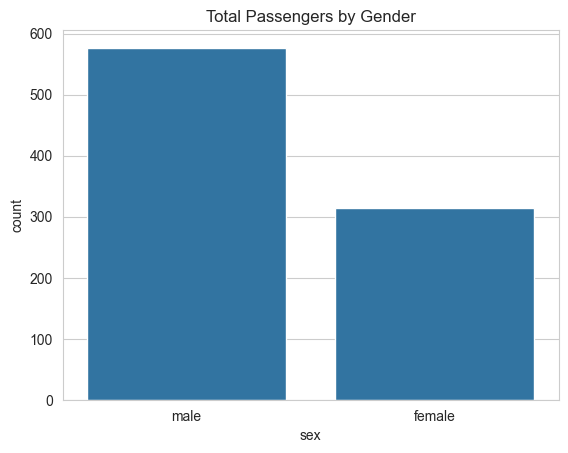

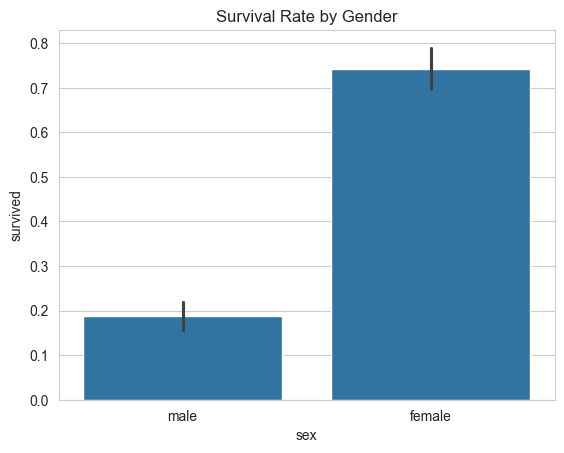

In [4]:
df_gender = df.groupby('sex').agg(
    total_count  = ('sex','count'),
    survived_count = ('survived','sum'),
    survival_rate = ('survived','mean')
)
print(df_gender)

sns.set_style("whitegrid")
sns.countplot(data=df,x='sex')
plt.title('Total Passengers by Gender')
plt.show
plt.figure()
sns.barplot(data=df,x='sex',y='survived')
plt.title('Survival Rate by Gender')

### Observations and Reasons

Observations:  
Although the  number of male passengers was almost twice higher than females, female passengers accounted for the majority of survivors, and the survival rate of females(74.20%) was significantly higher than males(18.90). This indicates that gender is a strong feature to the model.  

Reasons:  
The reason might be the woman and children first principle, later in the age analysis, I will examine whether the children also have higher survival rate.

## Pcalss Analysis

        total_count  survived_count  survival_rate
pclass                                            
1               216             136       0.629630
2               184              87       0.472826
3               491             119       0.242363


Text(0.5, 1.0, 'Survival Rate by Pclass')

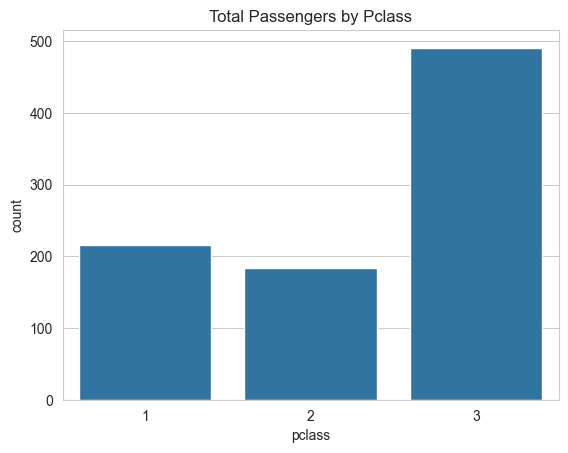

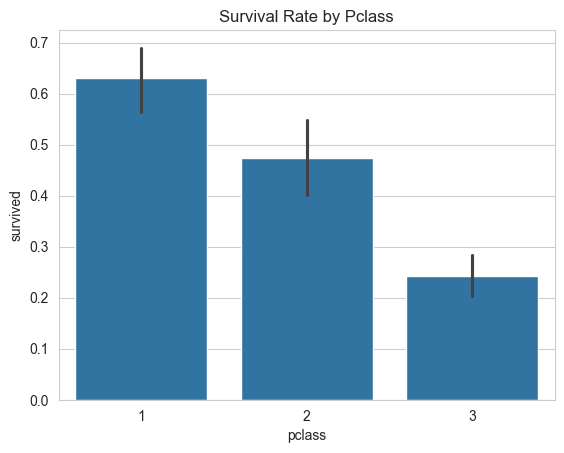

In [5]:
df_pclass = df.groupby('pclass').agg(
    total_count = ('pclass','count'),
    survived_count = ('survived','sum'),
    survival_rate = ('survived','mean')
)
print(df_pclass)

sns.countplot(data=df,x='pclass')
plt.title('Total Passengers by Pclass')
plt.figure()
sns.barplot(data=df,x='pclass',y='survived')
plt.title('Survival Rate by Pclass')

### Observations and Reasons  
  
Observations:  
Class 3 had the highest number of passengers but the lowest survival rate. There is a positive correlation between Pclass and survival rate:The higher the class, the higher survival rate.  

Reasons:  
Priority: Passengers in class 1 may have privileges during evacuation, they have the priority to resources. Moreover, the crew may put the safety of class 1 before other classes, like passengers in class 1 can receive better guidance.  
Location:  First class was usually on the upper decks which allow then to quickly get life saving resources and more simple escape route.

## Age Analysis

Text(0.5, 1.0, 'The Age Distribution')

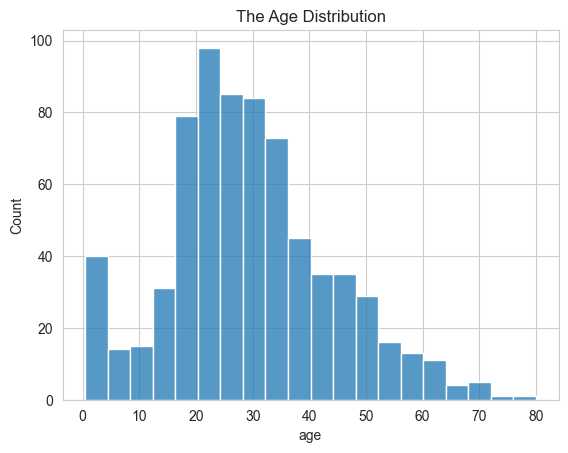

In [6]:
# Observe the age distribution
sns.histplot(df.age)
plt.title('The Age Distribution')

### Missing value:  

Corresponding to the observation in data overview, the distribution of the age is right skewed and is concentrated in 15-35 age range. Since the Name field gives the detailed titles, it provides a rough age range, so here I use median of the corresponding title group to fill in the missing values.

title
Mr        119
Miss       36
Mrs        17
Master      4
Dr          1
Name: count, dtype: int64
title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    str    
 4   sex          891 non-null    str    
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket 

Text(0.5, 1.0, 'The Filled Age Distribution')

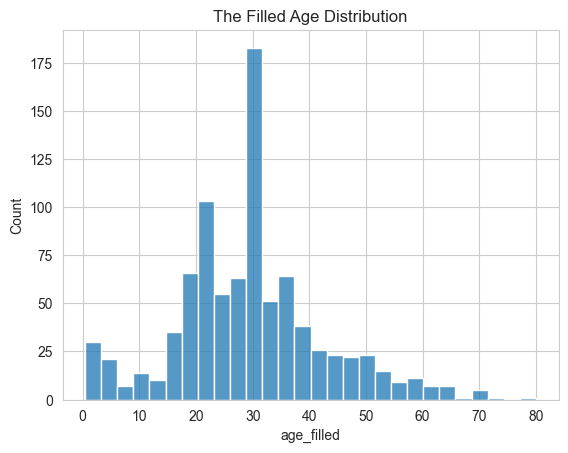

In [7]:
# Extract the title field
df['title'] = df.name.apply(lambda x:x.split(',')[1].split('.')[0].strip())
df.head()
df['title'].isnull().any()
# Observe titles of missing value
print(df.title[df.age.isnull()].value_counts())
print(df.title.value_counts())
# Fill in missing values
df['age_filled'] = df.groupby('title')['age'].transform(lambda x:x.fillna(x.median()))
df.info()
# Observe the age_filled distribution
sns.histplot(df.age_filled)
plt.title('The Filled Age Distribution')

### Observations:  

By Comparing the title distribution of missing samples and overall samples, I find the missing values focus on the most frequent titles like Mr, Miss, Mrs and Master. After filling, the age distribution still concentrate in the 15 - 35 age range and remains right skewed which is consistent with the title distribution of missing values.

           total_count  survived_count  survival_rate
age_group                                            
Children            64              38       0.593750
Teenager            75              32       0.426667
Adult              553             215       0.388788
Senior             199              57       0.286432


Text(0.5, 1.0, 'Survival Rate by Age Group')

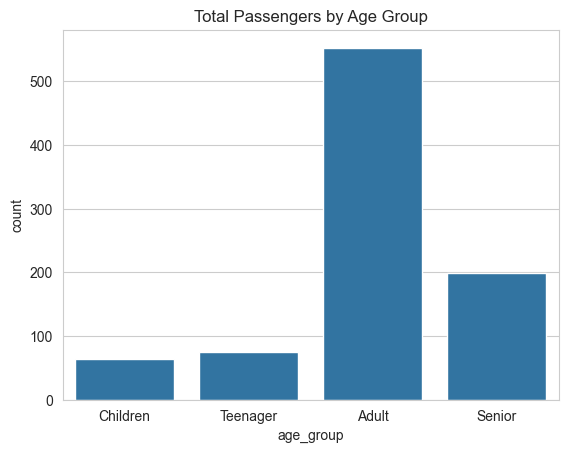

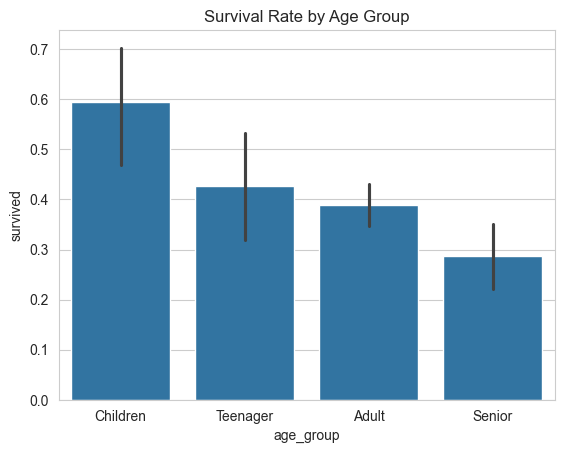

In [8]:
# Age grouping
def age_grouping(age):
    if age <= 10:
        return 'Children'
    elif age <= 18:
        return 'Teenager'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Senior'
df['age_group'] = df.age.apply(age_grouping)

df_age = df.groupby('age_group').agg(
    total_count = ('age_group','count'),
    survived_count = ('survived','sum'),
    survival_rate = ('survived','mean')
).sort_values(by='survival_rate',ascending=False)
print(df_age)

age_order = ['Children','Teenager','Adult','Senior']
sns.countplot(data=df,x='age_group',order=age_order)
plt.title('Total Passengers by Age Group')
plt.figure()
sns.barplot(data=df,x='age_group',y='survived',order=age_order)
plt.title('Survival Rate by Age Group')

### Observations and Reasons  

Observations:

The bar chart shows a decline in survival rate as age increases and the survival rate of children(almost 60%) is nearly double of the senior group.  
What's more, as the adult passengers account for the majority of the samples, its survival rate(38.88%) is close to the overall(38.38%).  

Reasons:  
The reason might be the woman and children first principle.

## SibSp and Parch Analysis

family
0     537
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64


Text(0.5, 1.0, 'The Distribution of Family Size')

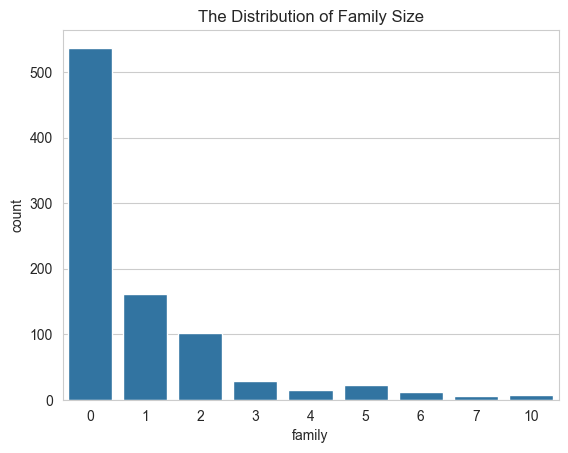

In [9]:
# Merge the SibSp and Parch columns to get the total number of family members
df['family'] = df.sibsp + df.parch
print(df.family.value_counts())

sns.countplot(data=df,x='family')
plt.title('The Distribution of Family Size')

### Grouping  

The distribution of Family shows that most passengers traveled alone and there is a obvious gap from 102(2 companions) to 29(3 companions), so I divide passengers to 3 groups to examine whether there is a difference between different groups.  

Travel alone: 0  
Travel with <=2 family members: 1  
Travel with >=3 family members: 2  

             total_count  survived_count  survival_rate
family_size                                            
1                    263             148       0.562738
2                     91              31       0.340659
0                    537             163       0.303538


Text(0.5, 1.0, 'Survival Rate by Family Size')

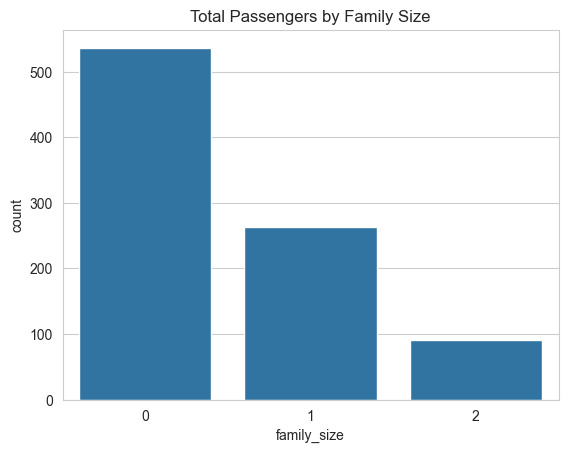

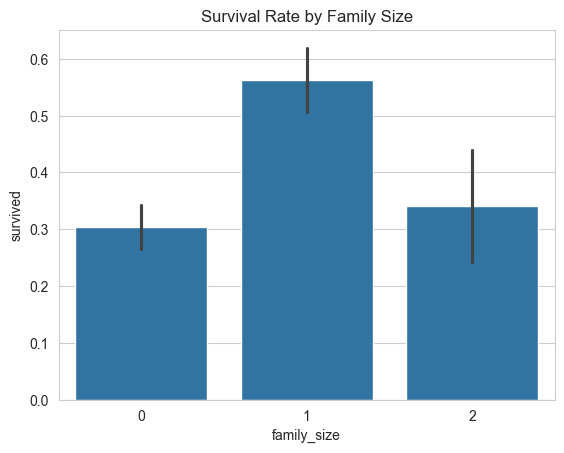

In [10]:
# Family grouping
df['family_size'] = df.family.apply(lambda x:0 if x == 0 else (1 if x <=2 else 2))
df_familysize = df.groupby('family_size').agg(
    total_count = ('family_size','count'),
    survived_count = ('survived','sum'),
    survival_rate = ('survived','mean')
).sort_values(by='survival_rate',ascending=False)
print(df_familysize)

sns.countplot(data=df,x='family_size')
plt.title('Total Passengers by Family Size')
plt.figure()
sns.barplot(data=df,x='family_size',y='survived')
plt.title('Survival Rate by Family Size')

### Observations and Reasons  

Observations:  
Passengers accompanied with 1 - 2 family members has a significant higher survival rate than passengers who traveled alone or with more than 3 companions.  

Reasons:  
Mutual assistance: improve survivial chances among family with small size.  
Low efficiency: may struggle to ensure everyone's safety among family with large size.

## Fare Analysis

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

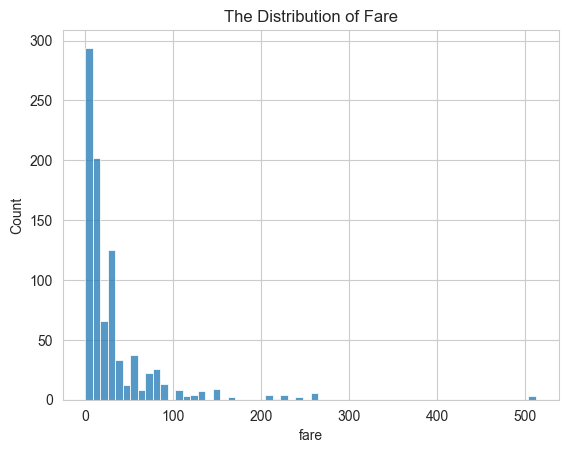

In [11]:
# Observe the fare distribution
sns.histplot(df.fare)
plt.title('The Distribution of Fare')
df.fare.describe()

### Log Transformation  

The distribution is right skewed and has a few extreme high values. These outliers affect the mean, std_dev and also make it difficult to observe the fares between 0 - 100 clearly, the range where prices are concentrated. Therefore, we use log to compress extreme values.

count    891.000000
mean       2.962246
std        0.969048
min        0.000000
25%        2.187218
50%        2.737881
75%        3.465736
max        6.240917
Name: log_fare, dtype: float64


C:\Users\56864\AppData\Local\Temp\ipykernel_2604\1371126465.py:6: RuntimeWarning: overflow encountered in exp
  df.log_fare.describe().apply(lambda x:np.exp(x)-1)


count           inf
mean      18.341359
std        1.635435
min        0.000000
25%        7.910388
50%       14.454200
75%       31.000000
max      512.329200
Name: log_fare, dtype: float64

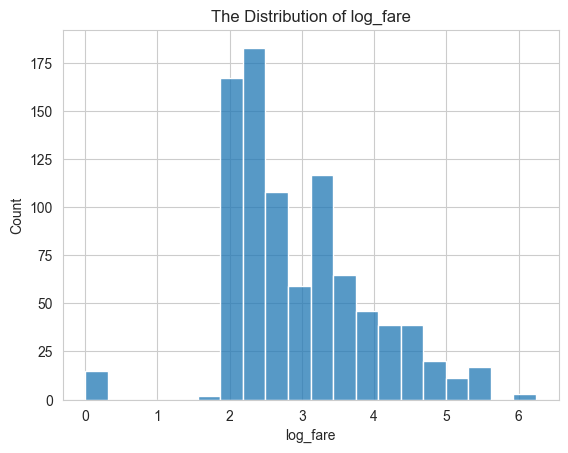

In [12]:
# log transformation
df['log_fare'] = df.fare.apply(np.log1p)
sns.histplot(df.log_fare,bins = 20)
plt.title('The Distribution of log_fare')
print(df.log_fare.describe())
df.log_fare.describe().apply(lambda x:np.exp(x)-1)

### Observations  

After transformation, the mean is about 18.34 which is lower than the original mean 32.2, and it is close to the median 14.45, so the dataset is more concentrated and the impact of outliers is reduced.

Text(0.5, 1.0, 'Log Fare Distribution by Survival Status')

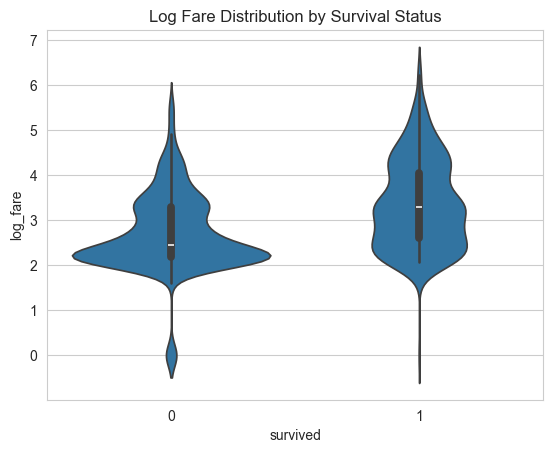

In [13]:
# Violinplot of log_fare by survival status
sns.violinplot(data=df,x='survived',y='log_fare')
plt.title('Log Fare Distribution by Survival Status')

### Observations:  

The median fare of survivors is significantly higher than the died group.  
In the death group, there is a significantly wider distribution in the low fare price, and then drop rapidly when the price rise up.  
In the survival group, the upper is much longer which may indicates passengers with extremely high price have the highest survival priority, and there is a noteable proportion of survivors in the higher price range.  
However, there is a peak around log_dare = 2.3, does it reflect the highest proportion of class 3 passengers pay the fare price at about 2.3?  
Overall, it reflects a positive correlation between fare and survival rate.

## Embarked Analysis

In [14]:
# Missing value
df['class_1'] = df.pclass.apply(lambda x:1 if x == 1 else 0)
df_port_class1 = df.groupby('embarked')['class_1'].agg(total_count = 'count', class1_count = 'sum', rate = 'mean')
print(df_port_class1)
df['embarked_filled'] = df.embarked.fillna('C')
df.info()

          total_count  class1_count      rate
embarked                                     
C                 168            85  0.505952
Q                  77             2  0.025974
S                 644           127  0.197205
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   passengerid      891 non-null    int64  
 1   survived         891 non-null    int64  
 2   pclass           891 non-null    int64  
 3   name             891 non-null    str    
 4   sex              891 non-null    str    
 5   age              714 non-null    float64
 6   sibsp            891 non-null    int64  
 7   parch            891 non-null    int64  
 8   ticket           891 non-null    str    
 9   fare             891 non-null    float64
 10  cabin            204 non-null    str    
 11  embarked         889 non-null    str    
 12  title            891 non-nu

### Missing value  

When using filters to explore the port data, I find passengers from port Q are almost from class 3, so I assume different port reflects different economic backgrounds of passengers. The two missing values were all from class 1, so I decided to fill in the values using port which has the highest proportion of class 1.

                 total_count  survived_count  survival_rate
embarked_filled                                            
C                        170              95       0.558824
Q                         77              30       0.389610
S                        644             217       0.336957


Text(0.5, 1.0, 'Survival Rate by Port')

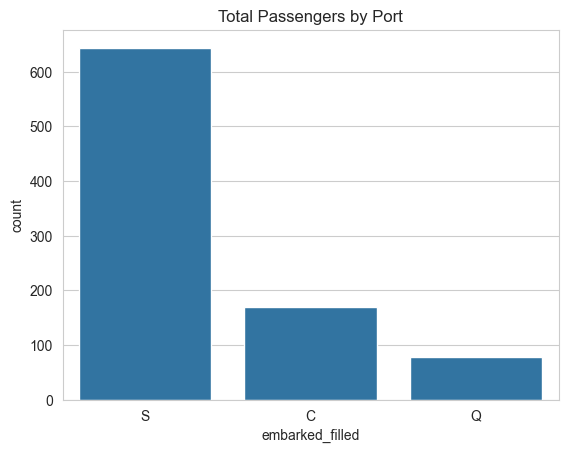

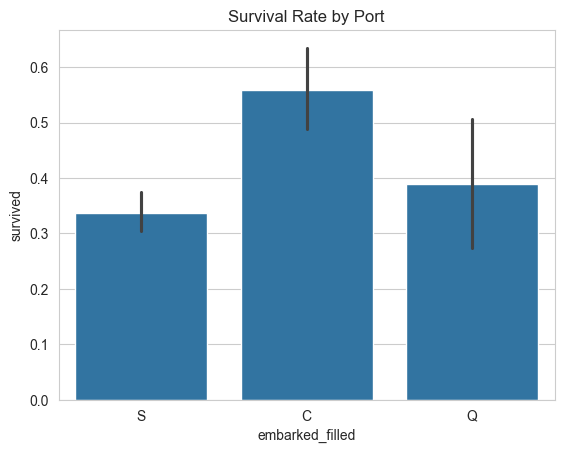

In [15]:
df_port = df.groupby('embarked_filled').agg(
    total_count = ('embarked_filled','count'),
    survived_count = ('survived','sum'),
    survival_rate = ('survived','mean')
)
print(df_port)

sns.countplot(data=df,x='embarked_filled')
plt.title('Total Passengers by Port')
plt.figure()
sns.barplot(data=df,x='embarked_filled',y='survived')
plt.title('Survival Rate by Port')

### Observations:

Port C with the highest proportion of class 1 also has the highest survival rate, but when it comes to port Q and port S, the distribution of pclass can not explain why port Q with almost all passengers from class 3 has a slight higer survival rate than port S. Therefore, there might be some other factors result in the contradiction.

## Fare & Pclass Analysis

Text(0.5, 1.0, 'Log Fare Distribution by Pclass')

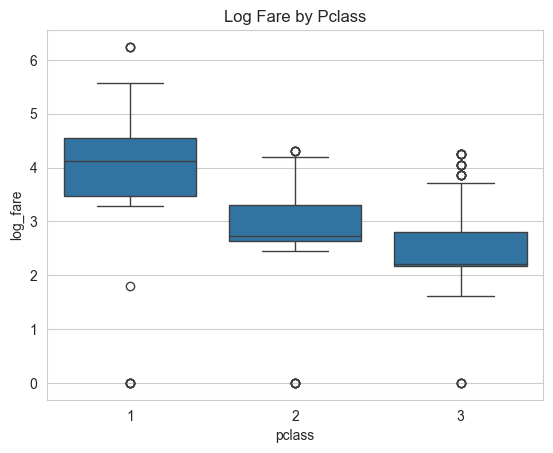

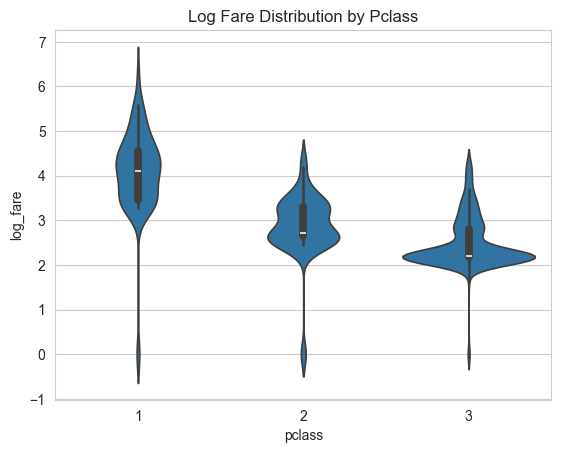

In [16]:
# Relationship between fare and pclass
sns.boxplot(x='pclass',y='log_fare',data=df)
plt.title('Log Fare by Pclass')

plt.figure()
sns.violinplot(x='pclass',y='log_fare',data=df)
plt.title('Log Fare Distribution by Pclass')

### Observations  

Fare price is significant different among different classes and the violin plot shows that the largest proportion of passengers concentrate at very low price levels.   
Outliers in class 3: why passengers in class 3 pay higher prices? — When I use the filter in excel to check the passengers in class 3 with the highest price(69.55), I find all of them are from the Sage family, so the ticket price may be the total fare for the family rather than the price allocated to each family member.

Text(0.5, 1.0, 'Log Fare Distribution by Survival Status')

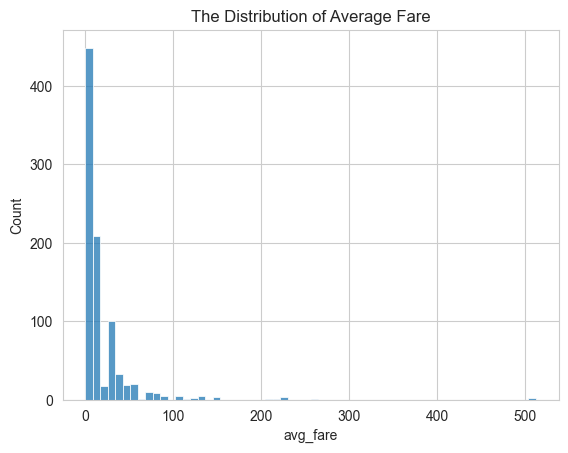

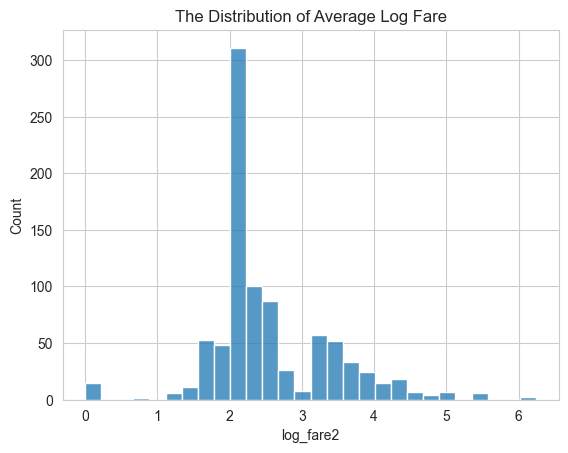

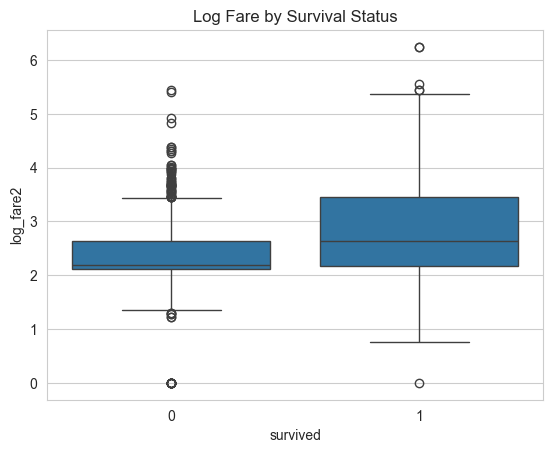

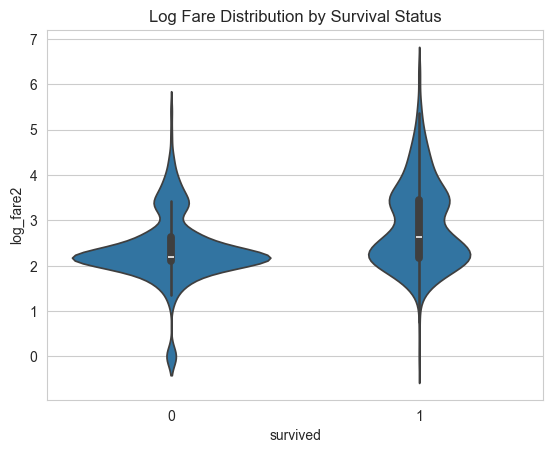

In [17]:
# Re-analysis of fares - using average fare
df['avg_fare'] = df.fare / (df.family + 1)
sns.histplot(df.avg_fare)
plt.title('The Distribution of Average Fare')

df['log_fare2'] = df.avg_fare.apply(np.log1p)
plt.figure()
sns.histplot(df.log_fare2)
plt.title('The Distribution of Average Log Fare')

plt.figure()
sns.boxplot(data=df,x='survived',y='log_fare2')
plt.title('Log Fare by Survival Status')

plt.figure()
sns.violinplot(data=df,x='survived',y='log_fare2')
plt.title('Log Fare Distribution by Survival Status')

### Obervations  

The histplot for log_fare2 is more concentrated and the number of samples paying high fare price decrease which indicates that average price reduce the influence from extreme high prices. There is a significant price difference between survivors and died passengers.  
By comparing with the former violin plot, the median price within survivals drop from about 3.5 to 2.5, and the distribution of victims become wider in low price(2.1), both indicates that the lowered fares for adults in family groups resulting in an overall decline in fare distribution.   

Why Outliers in non-survived group increase a lot?   

— The fare price is definitely different between children and adult, but the use of average calculation decreased adult fare and also increased the fare of children.   
— The family ticket pattern can be found in the variable Ticket, so by grouping family members from the same ticket number and counting the number of children and adult, the price can be recalculated.

### Recalculate the fare  

        family_counts  children_count  fare_price
ticket                                           
110152              3               0       86.50
110413              3               0       79.65
110465              2               0       52.00
110564              1               0       26.55
110813              1               0       75.25
count    891.0000
mean          inf
std           NaN
min        0.0000
25%        7.8542
50%       10.0750
75%       26.0000
max           inf
Name: fare_new, dtype: float64
count    891.000000
mean            inf
std             NaN
min        0.000000
25%        2.180892
50%        2.404690
75%        3.295837
max             inf
Name: log_fare3, dtype: float64


c:\Users\56864\Desktop\Titanic-2\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\56864\Desktop\Titanic-2\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Text(0.5, 1.0, 'New Log Fare Distribution by Survival Status')

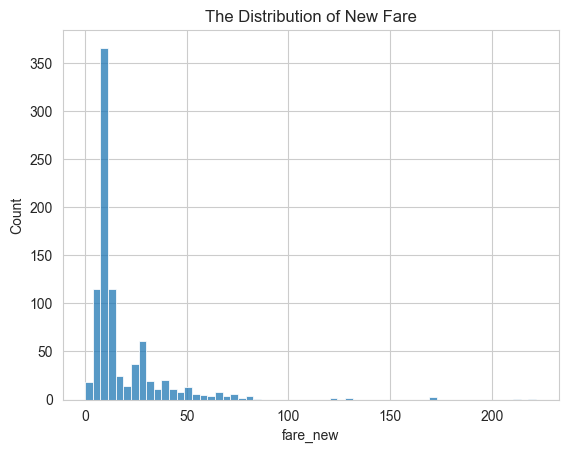

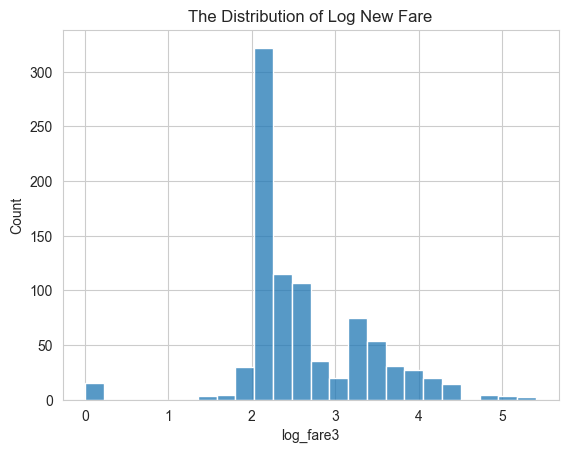

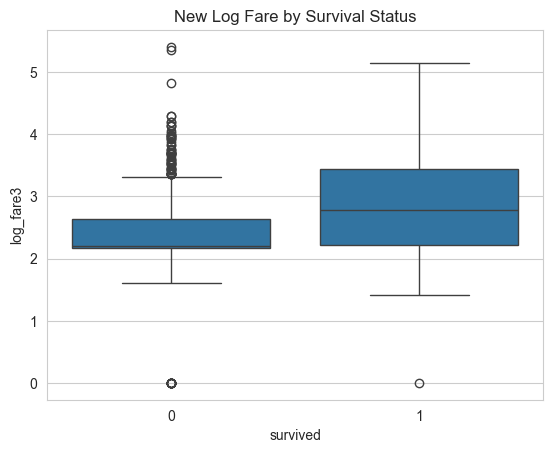

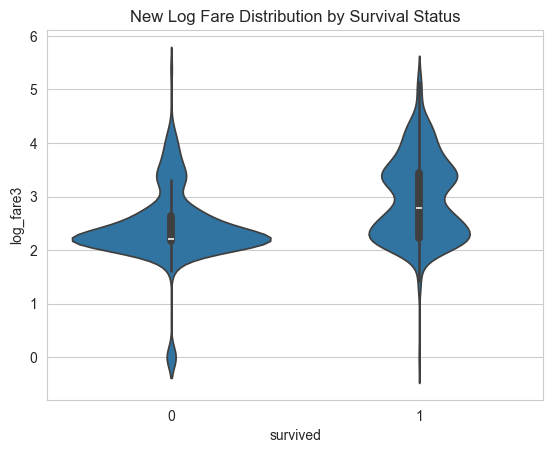

In [18]:
df['children'] = df.age_group.apply(lambda x:1 if x == 'Children' else 0)
df_family_status = df.groupby('ticket').agg(
    family_counts = ('ticket','count'),
    children_count = ('children','sum'),
    fare_price = ('fare',max)
)
print(df_family_status.head())
sum(df_family_status.family_counts)
df_family_status['adult_count'] = df_family_status.family_counts - df_family_status.children_count
df_family_status['adult_price'] = (df_family_status.fare_price - df_family_status.children_count * 4) / df_family_status.adult_count

dic_adult_price = df_family_status.adult_price.to_dict()
df['fare_new'] = df.apply(lambda x:0 if x['children'] == 4 else dic_adult_price[x['ticket']],axis=1)

# The distrbution of new fare
sns.histplot(df.fare_new)
plt.title('The Distribution of New Fare')
print(df.fare_new.describe())

df['log_fare3'] = df.fare_new.apply(np.log1p)
plt.figure()
sns.histplot(df.log_fare3)
plt.title('The Distribution of Log New Fare')
print(df.log_fare3.describe())

plt.figure()
sns.boxplot(data=df,x='survived',y='log_fare3')
plt.title('New Log Fare by Survival Status')

plt.figure()
sns.violinplot(data=df,x='survived',y='log_fare3')
plt.title('New Log Fare Distribution by Survival Status')


### Question  

Is it correct to directly use variable ticket as divisor, because I find even the fare impact in class 1 disappeared after use the new fare price.  
Moreover, how to define the standard to distribute price between adult and children. For adlt section, it seems use the average of rest fare price isn't correct.   
The following analysis about fare remain the previous version based on the average value.

Text(0.5, 1.0, 'New Log Fare Distribution by Pclass')

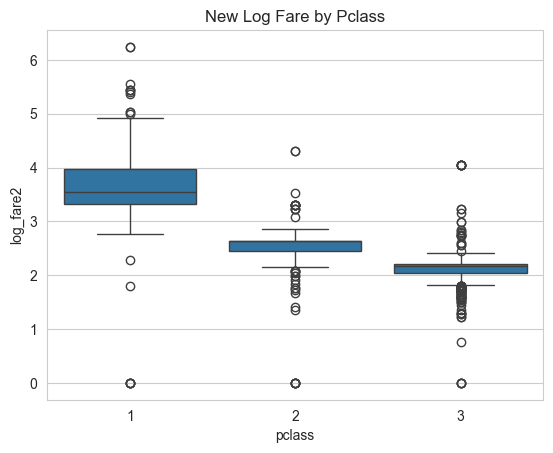

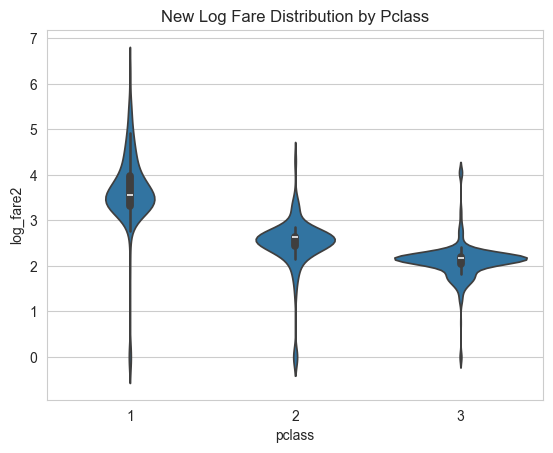

In [19]:
# Re-analysis relationship between fare and pclass 
sns.boxplot(data=df,x='pclass',y='log_fare2')
plt.title('New Log Fare by Pclass')
plt.figure()
sns.violinplot(data=df,x='pclass',y='log_fare2')
plt.title('New Log Fare Distribution by Pclass')

Text(0.5, 1.0, 'Survival Effects of Fare in Pclass 3')

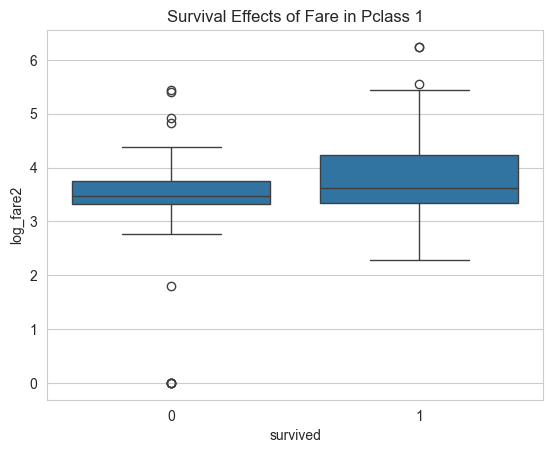

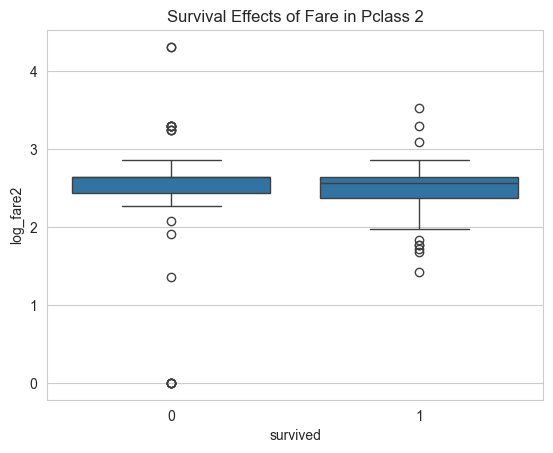

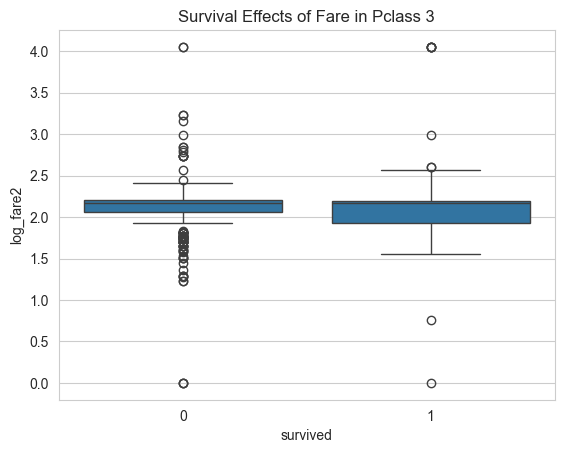

In [20]:
# Survival effects of fare with fixed class
sns.boxplot(x='survived',y='log_fare2',data=df[df.pclass == 1])
plt.title('Survival Effects of Fare in Pclass 1')
plt.figure()
sns.boxplot(x='survived',y='log_fare2',data=df[df.pclass == 2])
plt.title('Survival Effects of Fare in Pclass 2')
plt.figure()
sns.boxplot(x='survived',y='log_fare2',data=df[df.pclass == 3])
plt.title('Survival Effects of Fare in Pclass 3')

### Observations  

Pclass 1: The mean and median in survival group is obvious higher than non-survival group.The survival group has higher upper limit which means people who pays extreme high price survivrd. The box of died group concentrated in relatively lower price range in class 1.  
Pclass 2: The median of survivors in class 2 even lower than death group. Is there some other factors infulence class 2?  
Pclass 3: The median of survivors almost the same as death group and there are plenty of upper outliers in death group which means even paying a higher price, passengers still cannot survive.  
Overall: The price is only significant in class 1, if the passenger was in class 2 and 3, the higher price will not provide a higher possibility to survive and it seems that some other factors have more impact.

## Pclass & Gender Analysis

        total_count  survived_count  survival_rate
sex                                               
female           94              91       0.968085
male            122              45       0.368852
        total_count  survived_count  survival_rate
sex                                               
female           76              70       0.921053
male            108              17       0.157407
        total_count  survived_count  survival_rate
sex                                               
female          144              72       0.500000
male            347              47       0.135447


Text(0.5, 1.0, 'Survival Rate by Gender and Pclass')

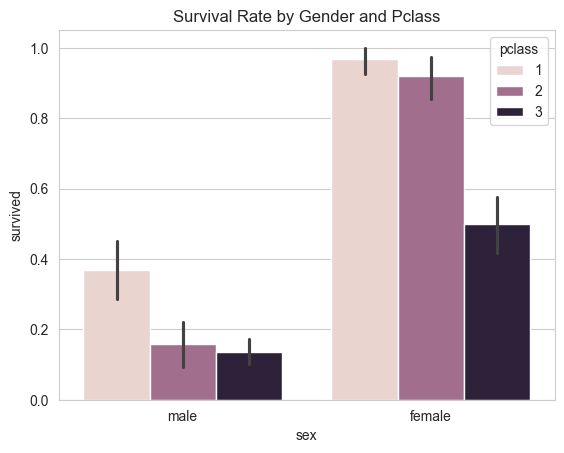

In [21]:
df_pclass1 = df[df.pclass == 1].groupby('sex').agg(
    total_count = ('sex','count'),
    survived_count = ('survived','sum'),
    survival_rate = ('survived','mean')
)
print(df_pclass1)

df_pclass2 = df[df.pclass == 2].groupby('sex').agg(
    total_count = ('sex','count'),
    survived_count = ('survived','sum'),
    survival_rate = ('survived','mean')
)
print(df_pclass2)

df_pclass3 = df[df.pclass == 3].groupby('sex').agg(
    total_count = ('sex','count'),
    survived_count = ('survived','sum'),
    survival_rate = ('survived','mean')
)
print(df_pclass3)

sns.barplot(data=df,x='sex',y='survived',hue='pclass')
plt.title('Survival Rate by Gender and Pclass')

### Observations  

The impact from gender is really significant, the survival rate in class 1 and 2 is larger than 90% which may explain the reason for higher fare price of death group in class 2.  
The survival rate of female in class 3 is much lower than other classes but still significant higher than male and it also reveals that the priority from different social class, even a passenger is a female, if she comes from class 3, she still face a much lower chance of survival than women in higher class.

## Embarked & Gender Analysis

embarked
Q    0.467532
C    0.434524
S    0.315217
Name: sex_numeric, dtype: float64
        total_count  survived_count  survival_rate
sex                                               
female           36              27       0.750000
male             41               3       0.073171
        total_count  survived_count  survival_rate
sex                                               
female           73              64       0.876712
male             95              29       0.305263
        total_count  survived_count  survival_rate
sex                                               
female          203             140       0.689655
male            441              77       0.174603


Text(0.5, 1.0, 'Survival Rate by Gender and Port')

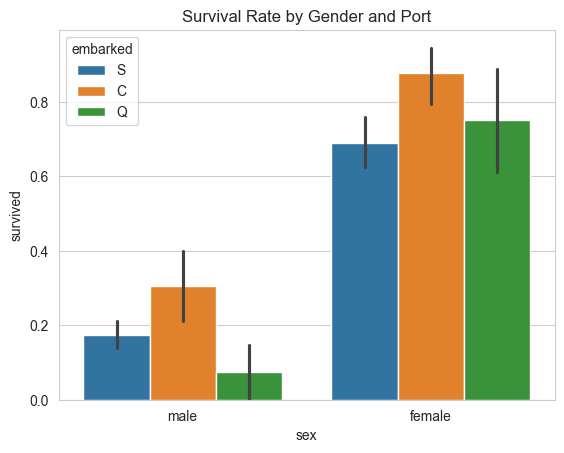

In [22]:
df['sex_numeric'] = df.sex.apply(lambda x:1 if x == 'female' else 0)
df_port_gender = df.groupby('embarked')['sex_numeric'].mean().sort_values(ascending=False)
print(df_port_gender)

df_portq = df[df.embarked == 'Q'].groupby('sex').agg(
    total_count = ('sex','count'),
    survived_count = ('survived','sum'),
    survival_rate = ('survived','mean')
)
print(df_portq)

df_portc = df[df.embarked == 'C'].groupby('sex').agg(
    total_count = ('sex','count'),
    survived_count = ('survived','sum'),
    survival_rate = ('survived','mean')
)
print(df_portc)

df_ports = df[df.embarked == 'S'].groupby('sex').agg(
    total_count = ('sex','count'),
    survived_count = ('survived','sum'),
    survival_rate = ('survived','mean')
)
print(df_ports)

sns.barplot(data=df,x='sex',y='survived',hue='embarked')
plt.title('Survival Rate by Gender and Port')


### Observations  

The proportion of females in port Q is much higher than port S, and it may explain why survival rate in port Q(majority from class 3) is higher than port S as the gender has greater impact.  

Question: In previous analysis of passenger class and gender, female passengers in class 3 show a significantly lower survival rate than other classes However, here females from port Q (almost all in class 3) have a higher survival rate than females from Port S.

## Conclusions  

The EDA shows that gender, Pclass, age, fare, and family size are likely to be the most influential factors affecting survival. Gender priority is higher than class in my analysis and the effect of fare is only signicant in calss 1. It seems that a young girl in class 1 who embarked from port C and was accompanied by her parents has the highest chance of survival.